In [1]:
%reset -f
%matplotlib inline


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ROOT = Path("oulad_clustered_student_engagement")
DATA_RAW = ROOT / "data" / "raw"

studentInfo = pd.read_csv(DATA_RAW / "studentInfo.csv")
studentVle = pd.read_csv(DATA_RAW / "studentVle.csv") #large data --load only when needed
assessments = pd.read_csv(DATA_RAW / "assessments.csv")
studentAssessment = pd.read_csv(DATA_RAW / "studentAssessment.csv")
courses = pd.read_csv(DATA_RAW / "courses.csv")
vle = pd.read_csv(DATA_RAW / "vle.csv")
studentReg = pd.read_csv(DATA_RAW / "studentRegistration.csv")

Data Cleaning: Removing the students who enrolled and unenrolled before the start of the course\. There are no students who unenrolled and enrolled again for the same course and the same presentation\.

In [4]:
# Identify students who unregistered before course start
neg_unreg = studentReg[
    studentReg["date_unregistration"].notna() &
    (studentReg["date_unregistration"] < 0)
]

neg_keys = neg_unreg[["id_student", "code_module", "code_presentation"]].drop_duplicates()


# Build keys to match exact student-course-presentation
studentInfo["key"] = (
    studentInfo["id_student"].astype(str) + "|" +
    studentInfo["code_module"].astype(str) + "|" +
    studentInfo["code_presentation"].astype(str)
)

neg_keys["key"] = (
    neg_keys["id_student"].astype(str) + "|" +
    neg_keys["code_module"].astype(str) + "|" +
    neg_keys["code_presentation"].astype(str)
)

# Remove only those rows
before = studentInfo.shape[0]
studentInfo = studentInfo[~studentInfo["key"].isin(neg_keys["key"])]
after = studentInfo.shape[0]

# Drop helper column
studentInfo = studentInfo.drop(columns=["key"])

print("Removed rows:", before - after)


Removed rows: 2678


In [5]:

studentInfo[[
    "studied_credits",
    "num_of_prev_attempts"
]].describe()

# describe_df(studentVle, "studentVle")
courses["module_presentation_length"].describe()
studentVle[["date", "sum_click"]].describe()
assessments[["date", "weight"]].describe()

,date,weight
count,195.000000,206.000000
mean,145.005128,20.873786
std,76.001119,30.384224
min,12.000000,0.000000
25%,71.000000,0.000000
50%,152.000000,12.500000
75%,222.000000,24.250000
max,261.000000,100.000000


studentInfo shape: (29915, 12)

Missing values (studentInfo):
imd_band                1054
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

Final result counts:
final_result
Pass           12361
Withdrawn       7480
Fail            7050
Distinction     3024
Name: count, dtype: int64


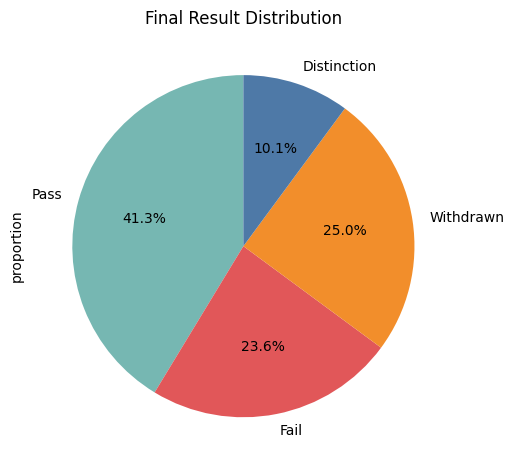

In [25]:
# -----------------------------
# 0) Minimal cleaning / standardization
# -----------------------------
si = studentInfo.copy()

# Normalize common categorical fields (safe + helpful for plots)
cat_cols = ["gender", "region", "highest_education", "imd_band", "age_band", "disability", "final_result"]
for c in cat_cols:
    if c in si.columns:
        si[c] = si[c].astype("string").str.strip()

# Optional: consistent ordering for final_result (if present)
final_order = ["Pass", "Fail", "Withdrawn", "Distinction"]
si["final_result"] = pd.Categorical(si["final_result"], categories=final_order, ordered=True)

# -----------------------------
# 1) Quick baseline summaries
# -----------------------------
print("studentInfo shape:", si.shape)
print("\nMissing values (studentInfo):")
print(si.isna().sum().sort_values(ascending=False))

print("\nFinal result counts:")
print(si["final_result"].value_counts(dropna=False))

# -----------------------------
# 2) Plot 1 — Outcome distribution (count) --make it to Pie Chart
# -----------------------------
outcome_counts = si["final_result"].value_counts(dropna=False).sort_index()
plt.figure()

colors = ["#76B7B2", "#E15759", "#F28E2B","#4E79A7"]
outcome_pct = (si["final_result"].value_counts(normalize=True, dropna=False).sort_index() * 100)
outcome_pct.plot(kind="pie",autopct="%.1f%%",startangle=90,colors=colors)

plt.title("Final Result Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

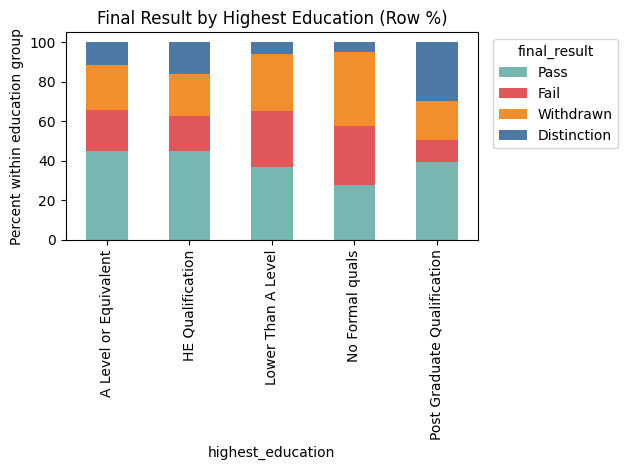

In [28]:
edu_outcome = pd.crosstab(si["highest_education"], si["final_result"], normalize="index") * 100
edu_outcome = edu_outcome.loc[edu_outcome.sum(axis=1).sort_values(ascending=False).index]  # sort by size/coverage

plt.figure()
edu_outcome.plot(kind="bar", stacked=True,
    color=colors)
plt.title("Final Result by Highest Education (Row %)")
plt.xlabel("highest_education")
plt.ylabel("Percent within education group")
plt.legend(title="final_result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

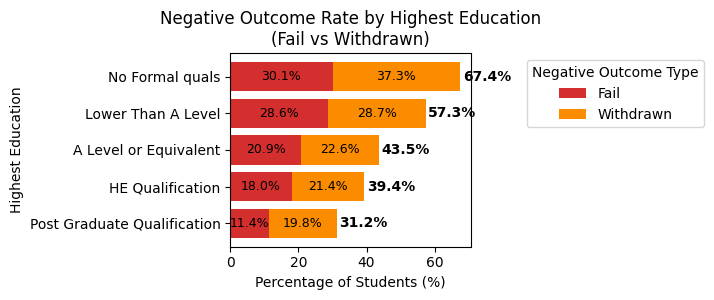

In [31]:
# Keep only Fail and Withdrawn
neg = si[si["final_result"].isin(["Fail", "Withdrawn"])]


# Percentage distribution of Fail vs Withdrawn within each education group
edu_outcome_split = (
    pd.crosstab(
        neg["highest_education"],
        neg["final_result"],
        normalize="index"
    ) * 100
)

si["is_negative_outcome"] = si["final_result"].isin(["Fail", "Withdrawn"])
risk_by_edu = ( si.groupby("highest_education")["is_negative_outcome"] .mean() .sort_values(ascending=False) .mul(100) .rename("neg_outcome_rate_%") )

# Overall negative outcome rate (already computed)
risk_total = risk_by_edu.loc[edu_outcome_split.index]

# Convert split % to absolute % of total population
edu_fail_pct = risk_total * (edu_outcome_split["Fail"] / 100)
edu_withdraw_pct = risk_total * (edu_outcome_split["Withdrawn"] / 100)

# Combine into one dataframe
stacked_risk = pd.DataFrame({
    "Fail": edu_fail_pct,
    "Withdrawn": edu_withdraw_pct
}).sort_values(by=["Fail", "Withdrawn"], ascending=False)

plt.figure(figsize=(8, 3.1))

plt.barh(
    stacked_risk.index,
    stacked_risk["Fail"],
    color="#D32F2F",
    label="Fail"
)

plt.barh(
    stacked_risk.index,
    stacked_risk["Withdrawn"],
    left=stacked_risk["Fail"],
    color="#FB8C00",
    label="Withdrawn"
)

plt.gca().invert_yaxis()

plt.title("Negative Outcome Rate by Highest Education\n(Fail vs Withdrawn)")
plt.xlabel("Percentage of Students (%)")
plt.ylabel("Highest Education")

# --- Annotate inner segments ---
for i, (fail, withdraw) in enumerate(
    zip(stacked_risk["Fail"], stacked_risk["Withdrawn"])
):
    if fail > 1:
        plt.text(fail / 2, i, f"{fail:.1f}%", va="center", ha="center",
                 color="black", fontsize=9)
    if withdraw > 1:
        plt.text(fail + withdraw / 2, i, f"{withdraw:.1f}%", va="center",
                 ha="center", color="black", fontsize=9)

# --- Annotate TOTAL negative outcome % at bar end ---
total_neg = stacked_risk.sum(axis=1)

for i, total in enumerate(total_neg):
    plt.text(
        total + 0.8,      # slight offset to the right of the bar
        i,
        f"{total:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.legend(title="Negative Outcome Type", bbox_to_anchor=(1.2, 1), loc="upper left")
plt.tight_layout()
plt.show()


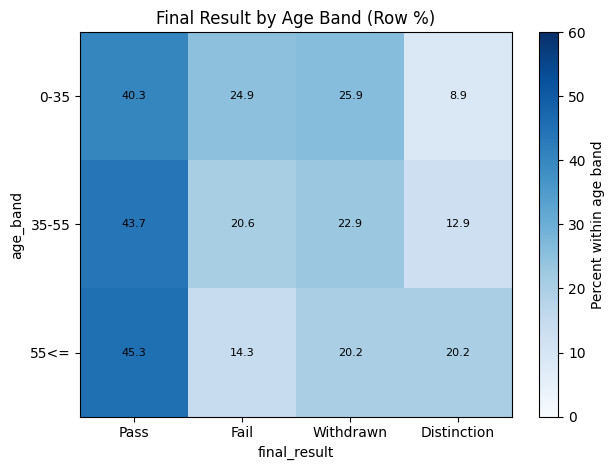

In [9]:
# -----------------------------
# 4) Plot 3 — Heatmap: age_band × final_result (row-normalized %)
# -----------------------------
age_outcome = pd.crosstab(si["age_band"], si["final_result"], normalize="index") * 100

plt.figure()
plt.imshow(age_outcome.values, aspect="auto", cmap="Blues", vmin=0, vmax=60)
plt.title("Final Result by Age Band (Row %)")
plt.xlabel("final_result")
plt.ylabel("age_band")
plt.xticks(range(age_outcome.shape[1]), age_outcome.columns, rotation=0)
plt.yticks(range(age_outcome.shape[0]), age_outcome.index)

# annotate cells
for i in range(age_outcome.shape[0]):
    for j in range(age_outcome.shape[1]):
        val = age_outcome.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.colorbar(label="Percent within age band")
plt.tight_layout()
plt.show()

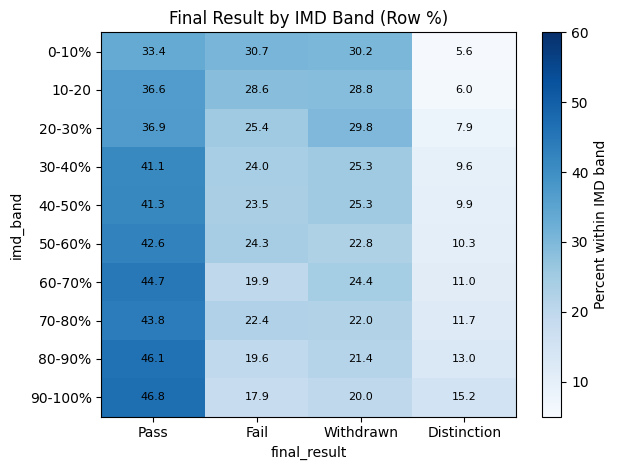

In [10]:
# -----------------------------
# 5) Plot 4 — Heatmap: IMD band × final_result (row-normalized %)
# -----------------------------
imd_outcome = pd.crosstab(si["imd_band"], si["final_result"], normalize="index") * 100
# Keep IMD in logical order if formatted like '0-10%', '10-20%', ...
imd_outcome = imd_outcome.reindex(sorted(imd_outcome.index, key=lambda x: (str(x).split("-")[0].replace("%","") if pd.notna(x) else "999")))

plt.figure()
plt.imshow(imd_outcome.values, aspect="auto", cmap="Blues", vmin=5, vmax=60)#YlGnBu
plt.title("Final Result by IMD Band (Row %)")
plt.xlabel("final_result")
plt.ylabel("imd_band")
plt.xticks(range(imd_outcome.shape[1]), imd_outcome.columns, rotation=0)
plt.yticks(range(imd_outcome.shape[0]), imd_outcome.index)

for i in range(imd_outcome.shape[0]):
    for j in range(imd_outcome.shape[1]):
        val = imd_outcome.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.colorbar(label="Percent within IMD band")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

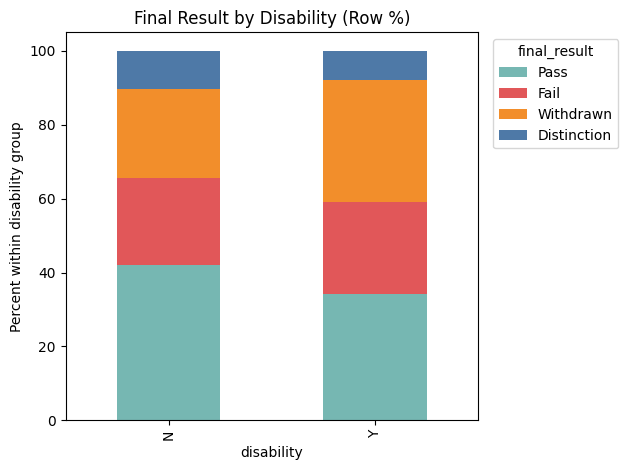

In [11]:
# -----------------------------
# 6) Plot 5 — Stacked bar: disability vs final_result (row %)
# -----------------------------
dis_outcome = pd.crosstab(si["disability"], si["final_result"], normalize="index") * 100

plt.figure()
dis_outcome.plot(kind="bar", stacked=True, color = colors)
plt.title("Final Result by Disability (Row %)")
plt.xlabel("disability")
plt.ylabel("Percent within disability group")
plt.legend(title="final_result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [12]:
# 2️⃣ Early Assessment Behaviour (Weeks 0–4) — CODE ONLY
# Uses: studentAssessment, assessments, studentInfo
# Variable rename: ass -> asg

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Parameters
# -----------------------------
EARLY_DAYS_END = 28  # 0–4 weeks
VALID_OUTCOMES = ["Pass", "Fail", "Withdrawn", "Distinction"]

# -----------------------------
# 1) Build assessment master
# -----------------------------
asg = assessments.copy()
sa = studentAssessment.copy()
si = studentInfo[["id_student", "code_module", "code_presentation", "final_result"]].copy()

asg["date"] = pd.to_numeric(asg["date"], errors="coerce")
asg["weight"] = pd.to_numeric(asg["weight"], errors="coerce")
sa["score"] = pd.to_numeric(sa["score"], errors="coerce")
sa["date_submitted"] = pd.to_numeric(sa["date_submitted"], errors="coerce")

asg_early = asg[asg["date"].between(0, EARLY_DAYS_END)].copy()

# -----------------------------
# 2) Join studentAssessment ↔ assessments
# -----------------------------
sa_full = sa.merge(
    asg[["id_assessment", "code_module", "code_presentation", "date", "weight"]],
    on="id_assessment",
    how="left"
)

sa_early = sa_full[sa_full["date"].between(0, EARLY_DAYS_END)].copy()

sa_early = sa_early.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

sa_early = sa_early[sa_early["final_result"].isin(VALID_OUTCOMES)].copy()

# -----------------------------
# 3) Feature A: Early mean score
# -----------------------------
early_mean_score = (
    sa_early.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
           .agg(early_mean_score=("score", "mean"))
)

early_mean_score = early_mean_score.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

early_mean_score = early_mean_score[
    early_mean_score["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 4) Feature B: % missed early assessments
# -----------------------------
expected = si.merge(
    asg_early[["code_module", "code_presentation", "id_assessment"]],
    on=["code_module", "code_presentation"],
    how="inner"
)

submitted_early = sa_early[
    ["id_student", "code_module", "code_presentation", "id_assessment"]
].drop_duplicates()

expected = expected.merge(
    submitted_early.assign(submitted=1),
    on=["id_student", "code_module", "code_presentation", "id_assessment"],
    how="left"
)

expected["submitted"] = expected["submitted"].fillna(0)

missed_stats = (
    expected.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
            .agg(
                n_early_assessments=("id_assessment", "nunique"),
                n_submitted_early=("submitted", "sum")
            )
)

missed_stats["n_missed_early"] = (
    missed_stats["n_early_assessments"] - missed_stats["n_submitted_early"]
)

missed_stats["pct_missed_early"] = np.where(
    missed_stats["n_early_assessments"] > 0,
    100 * missed_stats["n_missed_early"] / missed_stats["n_early_assessments"],
    np.nan
)

missed_stats = missed_stats.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

missed_stats = missed_stats[
    missed_stats["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 5) Feature C: Time gap between submissions
# -----------------------------
sa_early_sorted = sa_early.sort_values(
    ["id_student", "code_module", "code_presentation", "date_submitted"]
)

sa_early_sorted["gap_days"] = (
    sa_early_sorted
    .groupby(["id_student", "code_module", "code_presentation"])["date_submitted"]
    .diff()
)

time_gap = (
    sa_early_sorted.groupby(
        ["id_student", "code_module", "code_presentation"], as_index=False
    )
    .agg(
        mean_gap_days=("gap_days", "mean"),
        median_gap_days=("gap_days", "median")
    )
)

time_gap = time_gap.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

time_gap = time_gap[
    time_gap["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 6) Feature D: Cumulative early score
# -----------------------------
sa_early["weighted_points"] = sa_early["score"] * (sa_early["weight"] / 100.0)

stu_day = (
    sa_early.groupby(
        ["id_student", "code_module", "code_presentation", "final_result", "date"],
        as_index=False
    )
    .agg(day_points=("weighted_points", "sum"))
)

stu_day = stu_day.sort_values(
    ["id_student", "code_module", "code_presentation", "date"]
)

stu_day["cum_points"] = (
    stu_day
    .groupby(["id_student", "code_module", "code_presentation"])["day_points"]
    .cumsum()
)

traj = (
    stu_day.groupby(["final_result", "date"], as_index=False)
           .agg(mean_cum_points=("cum_points", "mean"))
)


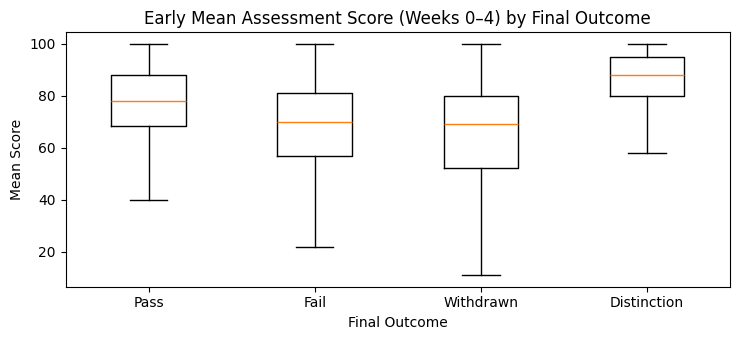

In [13]:
# Boxplot
data_for_box, labels = [], []
for out in VALID_OUTCOMES:
    vals = early_mean_score.loc[
        early_mean_score["final_result"] == out, "early_mean_score"
    ].dropna()
    if len(vals) > 0:
        data_for_box.append(vals)
        labels.append(out)

plt.figure(figsize=(7.5, 3.5))
plt.boxplot(data_for_box, labels=labels, showfliers=False)
plt.title("Early Mean Assessment Score (Weeks 0–4) by Final Outcome")
plt.xlabel("Final Outcome")
plt.ylabel("Mean Score")
plt.tight_layout()
plt.show()


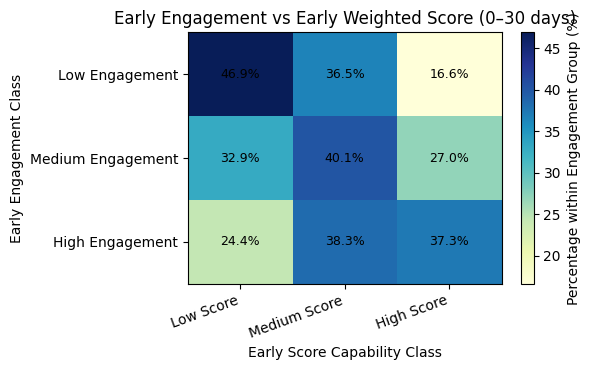

In [14]:
# =========================================================
# Early Engagement vs Early Weighted Score (EDA)
# - Heatmap + Sankey (NO interventions)
# - Early window is PARAMETERIZED (change ONE value below)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- EARLY WINDOW (MODIFY THIS) ----------
EARLY_WINDOW_DAYS = 30   # 1 month (change to 14, 21, 45, etc. to compare patterns)

# ---------- THRESHOLDS (MODIFY THESE) ----------
ENG_LOW_PCTL, ENG_HIGH_PCTL = 25, 75
SCORE_LOW_PCTL, SCORE_HIGH_PCTL = 25, 75

# -----------------------------
# 1) EARLY WEIGHTED SCORE per student-course-presentation
# -----------------------------
asg = assessments.copy()
sa = studentAssessment.copy()

asg["date"] = pd.to_numeric(asg["date"], errors="coerce")
asg["weight"] = pd.to_numeric(asg["weight"], errors="coerce")
sa["score"] = pd.to_numeric(sa["score"], errors="coerce")

# Early assessments by due date
asg_early = asg[asg["date"].between(0, EARLY_WINDOW_DAYS)].copy()

# Attach module/presentation + weight to student submissions
sa_full = sa.merge(
    asg_early[["id_assessment", "code_module", "code_presentation", "date", "weight"]],
    on="id_assessment",
    how="inner"
)

# Weighted points (score * assessment weight)
sa_full["weighted_points"] = sa_full["score"] * (sa_full["weight"] / 100.0)

# Aggregate early weighted score per student per course presentation
early_score = (
    sa_full.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
           .agg(early_weighted_score=("weighted_points", "sum"))
)

# -----------------------------
# 2) EARLY ENGAGEMENT (total clicks) per student-course-presentation
# -----------------------------
sv = studentVle.copy()
sv["date"] = pd.to_numeric(sv["date"], errors="coerce")
sv["sum_click"] = pd.to_numeric(sv["sum_click"], errors="coerce")

sv_early = sv[sv["date"].between(0, EARLY_WINDOW_DAYS)].copy()

early_eng = (
    sv_early.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
            .agg(early_total_clicks=("sum_click", "sum"))
)

# -----------------------------
# 3) Combine: only these two signals (score + engagement)
# -----------------------------
df = early_eng.merge(
    early_score,
    on=["id_student", "code_module", "code_presentation"],
    how="inner"
).copy()

# -----------------------------
# 4) Percentile-based classification (within EACH course presentation)
#    (fair comparison across different courses)
# -----------------------------
def add_percentile_classes(group):
    # Engagement thresholds in this course presentation
    eng_low = np.percentile(group["early_total_clicks"], ENG_LOW_PCTL)
    eng_high = np.percentile(group["early_total_clicks"], ENG_HIGH_PCTL)

    # Score thresholds in this course presentation
    sc_low = np.percentile(group["early_weighted_score"], SCORE_LOW_PCTL)
    sc_high = np.percentile(group["early_weighted_score"], SCORE_HIGH_PCTL)

    # Engagement class
    group["engagement_class"] = np.select(
        [
            group["early_total_clicks"] <= eng_low,
            group["early_total_clicks"] >= eng_high
        ],
        ["Low Engagement", "High Engagement"],
        default="Medium Engagement"
    )

    # Score class
    group["score_class"] = np.select(
        [
            group["early_weighted_score"] <= sc_low,
            group["early_weighted_score"] >= sc_high
        ],
        ["Low Score", "High Score"],
        default="Medium Score"
    )

    return group

df = (
    df.groupby(["code_module", "code_presentation"], group_keys=False)
      .apply(add_percentile_classes)
)

# Optional: enforce consistent order for plotting
eng_order = ["Low Engagement", "Medium Engagement", "High Engagement"]
score_order = ["Low Score", "Medium Score", "High Score"]
df["engagement_class"] = pd.Categorical(df["engagement_class"], categories=eng_order, ordered=True)
df["score_class"] = pd.Categorical(df["score_class"], categories=score_order, ordered=True)

# =========================================================
# PLOT A) HEATMAP (Engagement class × Score class)
# =========================================================
heat = pd.crosstab(df["engagement_class"], df["score_class"], normalize="index") * 100
heat = heat.reindex(index=eng_order, columns=score_order)

plt.figure(figsize=(6, 3.8))
plt.imshow(heat.values, aspect="auto", cmap="YlGnBu")
plt.colorbar(label="Percentage within Engagement Group (%)")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=20, ha="right")
plt.yticks(range(len(heat.index)), heat.index)

# annotate cells
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=9)

plt.title(f"Early Engagement vs Early Weighted Score (0–{EARLY_WINDOW_DAYS} days)")
plt.xlabel("Early Score Capability Class")
plt.ylabel("Early Engagement Class")
plt.tight_layout()
plt.show()


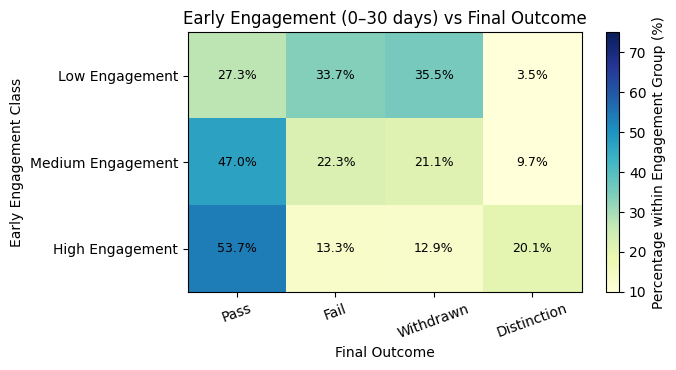

In [15]:
# =========================================================
# Early Engagement vs Final Outcome (EDA)
# - Heatmap + Sankey
# - Early window is PARAMETERIZED (change ONE value)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- EARLY WINDOW (CHANGE THIS) ----------
EARLY_WINDOW_DAYS = 30   # 1 month (try 14, 21, 45, etc.)

# ---------- ENGAGEMENT PERCENTILE THRESHOLDS ----------
ENG_LOW_PCTL = 25
ENG_HIGH_PCTL = 75

# -----------------------------
# 1) EARLY ENGAGEMENT (total clicks)
# -----------------------------
sv = studentVle.copy()
sv["date"] = pd.to_numeric(sv["date"], errors="coerce")
sv["sum_click"] = pd.to_numeric(sv["sum_click"], errors="coerce")

sv_early = sv[sv["date"].between(0, EARLY_WINDOW_DAYS)].copy()

early_eng = (
    sv_early.groupby(
        ["id_student", "code_module", "code_presentation"], as_index=False
    )
    .agg(early_total_clicks=("sum_click", "sum"))
)

# -----------------------------
# 2) ATTACH FINAL OUTCOME
# -----------------------------
si = studentInfo[
    ["id_student", "code_module", "code_presentation", "final_result"]
].copy()

df = early_eng.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="inner"
)

# Keep standard outcomes only
final_order = ["Pass", "Fail", "Withdrawn", "Distinction"]
df = df[df["final_result"].isin(final_order)].copy()

# -----------------------------
# 3) ENGAGEMENT PERCENTILE CLASSIFICATION
#    (within each course presentation)
# -----------------------------
def classify_engagement(group):
    low = np.percentile(group["early_total_clicks"], ENG_LOW_PCTL)
    high = np.percentile(group["early_total_clicks"], ENG_HIGH_PCTL)

    group["engagement_class"] = np.select(
        [
            group["early_total_clicks"] <= low,
            group["early_total_clicks"] >= high
        ],
        ["Low Engagement", "High Engagement"],
        default="Medium Engagement"
    )
    return group

df = (
    df.groupby(["code_module", "code_presentation"], group_keys=False)
      .apply(classify_engagement)
)

eng_order = ["Low Engagement", "Medium Engagement", "High Engagement"]
df["engagement_class"] = pd.Categorical(
    df["engagement_class"], categories=eng_order, ordered=True
)
df["final_result"] = pd.Categorical(
    df["final_result"], categories=final_order, ordered=True
)

# =========================================================
# PLOT A) HEATMAP — Engagement class × Final outcome
# =========================================================
heat = (
    pd.crosstab(
        df["engagement_class"],
        df["final_result"],
        normalize="index"
    ) * 100
).reindex(index=eng_order, columns=final_order)

plt.figure(figsize=(7, 3.8))
plt.imshow(heat.values, aspect="auto", cmap="YlGnBu", vmin = 10, vmax= 75)
plt.colorbar(label="Percentage within Engagement Group (%)")

plt.xticks(range(len(heat.columns)), heat.columns, rotation=20)
plt.yticks(range(len(heat.index)), heat.index)

# annotate
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=9)

plt.title(
    f"Early Engagement (0–{EARLY_WINDOW_DAYS} days) vs Final Outcome"
)
plt.xlabel("Final Outcome")
plt.ylabel("Early Engagement Class")
plt.tight_layout()
plt.show()


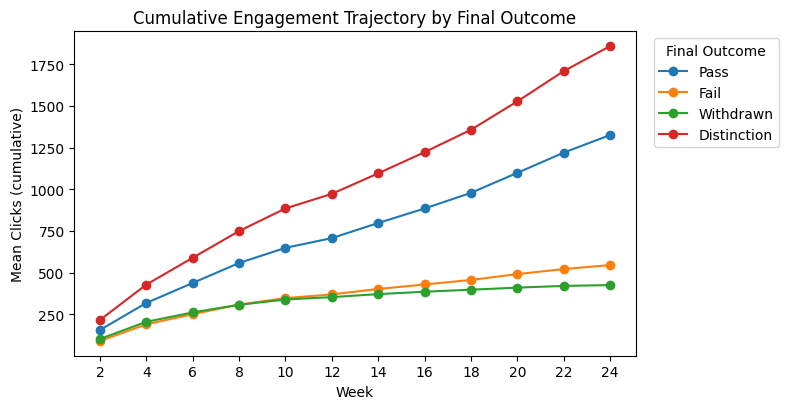

In [16]:
# Line chart: engagement trajectories by final outcome (Pass/Fail/Withdrawn/Distinction)
# Single chart with all outcomes.
# Uses: studentVle, studentInfo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------- SETTINGS (edit these) ----------
WEEK_POINTS = [2, 4, 6, 8, 10, 12,14,16,18,20,22,24]   # add more if you want: [2,4,6,8,10,12,14,16,...]
CUMULATIVE = True                   # True = cumulative clicks up to week; False = clicks within that week only
OUTCOME_ORDER = ["Pass", "Fail", "Withdrawn", "Distinction"]

# -----------------------------
# 1) Prepare early weekly engagement from studentVle
# -----------------------------
sv = studentVle[["id_student", "code_module", "code_presentation", "date", "sum_click"]].copy()
sv["date"] = pd.to_numeric(sv["date"], errors="coerce")
sv["sum_click"] = pd.to_numeric(sv["sum_click"], errors="coerce")
sv = sv.dropna(subset=["date", "sum_click"])

# Convert day -> week number (Week 1 starts at day 0)
sv["week"] = (sv["date"] // 7 + 1).astype(int)

# Keep only needed range
max_week = max(WEEK_POINTS)
sv = sv[sv["week"].between(1, max_week)].copy()

# Weekly clicks per student per course presentation
wk = (
    sv.groupby(["id_student", "code_module", "code_presentation", "week"], as_index=False)
      .agg(weekly_clicks=("sum_click", "sum"))
)

# -----------------------------
# 2) Attach final outcome
# -----------------------------
si = studentInfo[["id_student", "code_module", "code_presentation", "final_result"]].copy()
traj = wk.merge(si, on=["id_student", "code_module", "code_presentation"], how="inner")
traj = traj[traj["final_result"].isin(OUTCOME_ORDER)].copy()

# -----------------------------
# 3) Build trajectory values at WEEK_POINTS
# -----------------------------
# Create complete grid so missing weeks become 0 clicks
all_keys = traj[["id_student", "code_module", "code_presentation", "final_result"]].drop_duplicates()
grid = all_keys.assign(key=1).merge(
    pd.DataFrame({"week": range(1, max_week + 1), "key": 1}),
    on="key",
    how="outer"
).drop(columns="key")

traj_full = grid.merge(
    traj[["id_student", "code_module", "code_presentation", "final_result", "week", "weekly_clicks"]],
    on=["id_student", "code_module", "code_presentation", "final_result", "week"],
    how="left"
)
traj_full["weekly_clicks"] = traj_full["weekly_clicks"].fillna(0)

# Cumulative or per-week
traj_full = traj_full.sort_values(["id_student", "code_module", "code_presentation", "week"])
if CUMULATIVE:
    traj_full["value"] = (
        traj_full.groupby(["id_student", "code_module", "code_presentation"])["weekly_clicks"]
                 .cumsum()
    )
else:
    traj_full["value"] = traj_full["weekly_clicks"]

# Keep only the specific weeks you want to plot (2,4,6,...)
traj_points = traj_full[traj_full["week"].isin(WEEK_POINTS)].copy()

# Average across students (you can switch to median if you want)
avg_by_outcome = (
    traj_points.groupby(["final_result", "week"], as_index=False)
               .agg(mean_engagement=("value", "mean"))
)

# -----------------------------
# 4) Plot: one chart with all outcomes
# -----------------------------
plt.figure(figsize=(8, 4.2))

for outcome in OUTCOME_ORDER:
    sub = avg_by_outcome[avg_by_outcome["final_result"] == outcome].sort_values("week")
    if len(sub) > 0:
        plt.plot(sub["week"], sub["mean_engagement"], marker="o", label=outcome)

title_mode = "Cumulative" if CUMULATIVE else "Weekly"
plt.title(f"{title_mode} Engagement Trajectory by Final Outcome")
plt.xlabel("Week")
plt.ylabel("Mean Clicks" + (" (cumulative)" if CUMULATIVE else ""))
plt.xticks(WEEK_POINTS)
plt.legend(title="Final Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [17]:
def get_columns(dfs):
    return {f"df_{i}": df.columns.tolist() for i, df in enumerate(dfs)}



dfs = [studentInfo ,assessments ,studentAssessment , courses, vle, studentReg]
print(get_columns(dfs))

{'df_0': ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result'], 'df_1': ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight'], 'df_2': ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], 'df_3': ['code_module', 'code_presentation', 'module_presentation_length'], 'df_4': ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to'], 'df_5': ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']}


In [22]:
import base64, pathlib
pathlib.Path("tiny.txt").write_text("ok")

# make a tiny png via matplotlib and read it as bytes
import matplotlib.pyplot as plt
plt.plot([1,2],[1,4])
plt.savefig("t.png")
plt.close()

print("saved bytes:", pathlib.Path("t.png").stat().st_size)

saved bytes: 17415


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=915c48ff-4287-4f39-af89-419738985e00' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>